<font color="#CA0032"><h1 align="left">**Redes recurrentes profundas**</h1></font>

<font color="#6E6E6E"><h1 align="left">**Predicción de series temporales**</h1></font>

<h2 align="left">Manuel Sánchez-Montañés</h2>

<font color="#6E6E6E"><h2 align="left">manuel.smontanes@gmail.com</h2></font>

**Notebook: Manuel Sánchez-Montañés**

**Datos: Carlos Rosado**

### **Usaremos un esquema many to one:**

<img src="https://drive.google.com/uc?export=download&id=1iokh576AiK2iFhftPogSBsNXixAi-LBg" align="center" style="float" width="500">

In [1]:
COLAB = True

## <font color="#CA3532"> **1. Importar librerías**

In [2]:
import numpy as np
import pandas as pd

from keras.models import Sequential, load_model
from keras.layers import Dense, LSTM, GRU
from keras.callbacks import ModelCheckpoint

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score as R2_score

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import os

# fijo la semilla aleatoria por reproducibilidad
np.random.seed(7)

In [3]:
def download_file_from_google_drive(file_id, dest_file, unzip=False):
  aux = "'https://drive.usercontent.google.com/download?id={}&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280'".format(file_id)
  !wget $aux -O $dest_file
  if unzip:
    !unzip -qq -o $dest_file
    !rm $dest_file

## <font color="#CA3532"> **2. Carga de datos**

In [4]:
!ls

sample_data


In [5]:
if COLAB:
    download_file_from_google_drive(file_id='12QZpA_L1JncFIVEryee0aeL66Ep3xpOy', dest_file='./datos_pasajeros.csv')

data = pd.read_csv('datos_pasajeros.csv')
data.head(20)

--2026-05-28 10:14:09--  https://drive.usercontent.google.com/download?id=12QZpA_L1JncFIVEryee0aeL66Ep3xpOy&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19189 (19K) [application/octet-stream]
Saving to: ‘./datos_pasajeros.csv’

./datos_pasajeros.c 100%[===================>]  18.74K  --.-KB/s    in 0s      

2026-05-28 10:14:10 (50.5 MB/s) - ‘./datos_pasajeros.csv’ saved [19189/19189]



,fecha,mes,festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,1,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,0,2767,0,0
5,2015-01-06,1,1,1342,0,1
6,2015-01-07,1,0,3867,0,2
7,2015-01-08,1,0,3904,1,3
8,2015-01-09,1,0,3678,1,4
9,2015-01-10,1,0,2631,1,5


In [6]:
data2 = data.copy()
data2["festivo"] = list(data["festivo"].values[1:]) + [0]
data2 = data2.rename({"festivo": "mañana festivo"}, axis=1)
data2

,fecha,mes,mañana festivo,npasajeros,semana_mes,day_of_week
0,2015-01-01,1,0,1125,0,3
1,2015-01-02,1,0,3592,0,4
2,2015-01-03,1,0,3001,0,5
3,2015-01-04,1,0,2260,0,6
4,2015-01-05,1,1,2767,0,0
...,...,...,...,...,...,...
785,2017-02-24,2,0,4199,2,4
786,2017-02-25,2,0,2534,2,5
787,2017-02-26,2,0,1816,2,6
788,2017-02-27,2,0,3990,2,0


In [7]:
!ls -la

total 36
drwxr-xr-x 1 root root  4096 May 28 10:14 .
drwxr-xr-x 1 root root  4096 May 28 10:08 ..
drwxr-xr-x 4 root root  4096 May 26 13:25 .config
-rw-r--r-- 1 root root 19189 May 26  2023 datos_pasajeros.csv
drwxr-xr-x 1 root root  4096 May 26 13:25 sample_data


In [8]:
data.shape

(790, 6)

## <font color="#CA3532"> **3. Preprocesado inicial y visualización de datos**

In [9]:
type(data['fecha'][0])

str

In [10]:
# La fecha es un string, la pasamos a formato fecha de pandas:
data['fecha'] = pd.to_datetime(data['fecha'])
type(data['fecha'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [11]:
data['fecha']

,fecha
0,2015-01-01
1,2015-01-02
2,2015-01-03
3,2015-01-04
4,2015-01-05
...,...
785,2017-02-24
786,2017-02-25
787,2017-02-26
788,2017-02-27


In [12]:
fechas      = data['fecha'].values
target      = data['npasajeros'].values
mes         = data['mes'].values
festivo     = data['festivo'].values
semana      = data['semana_mes'].values
day_of_week = data['day_of_week'].values

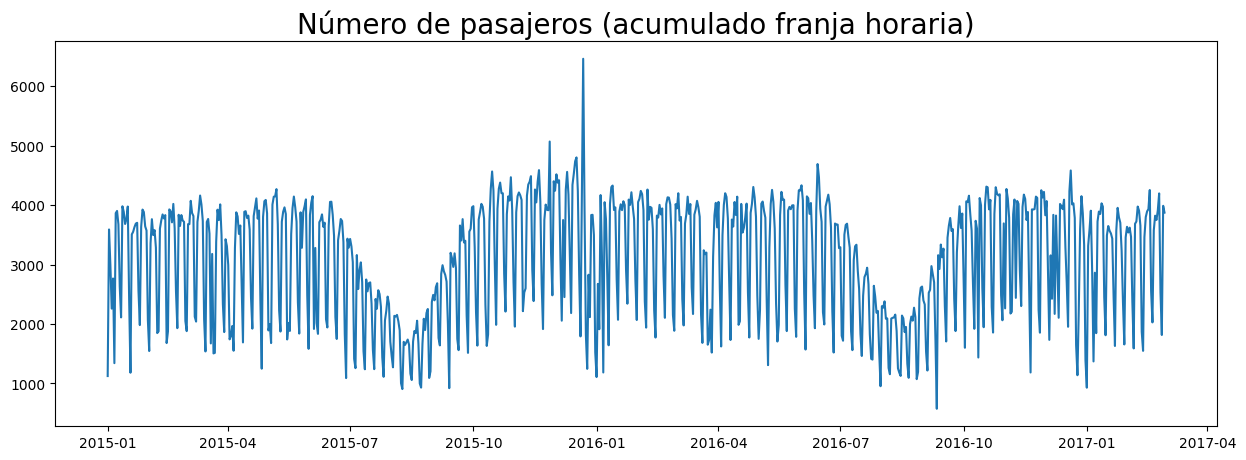

In [13]:
plt.figure(figsize=(15,5))
plt.plot(fechas, target)
plt.title('Número de pasajeros (acumulado franja horaria)',
          fontsize=20);

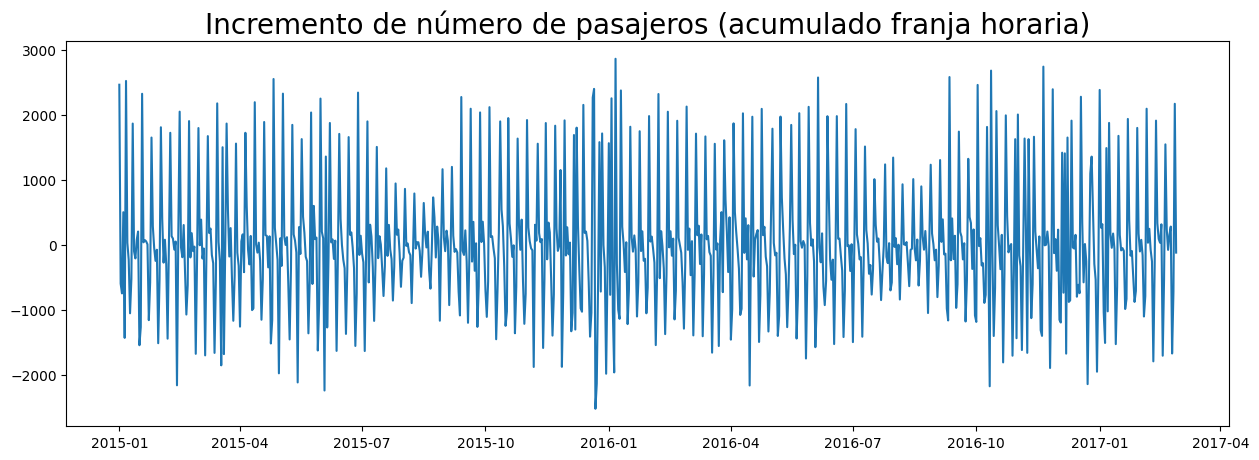

In [14]:
plt.figure(figsize=(15,5))
plt.plot(fechas[:-1], np.diff(target))
plt.title('Incremento de número de pasajeros (acumulado franja horaria)',
          fontsize=20);

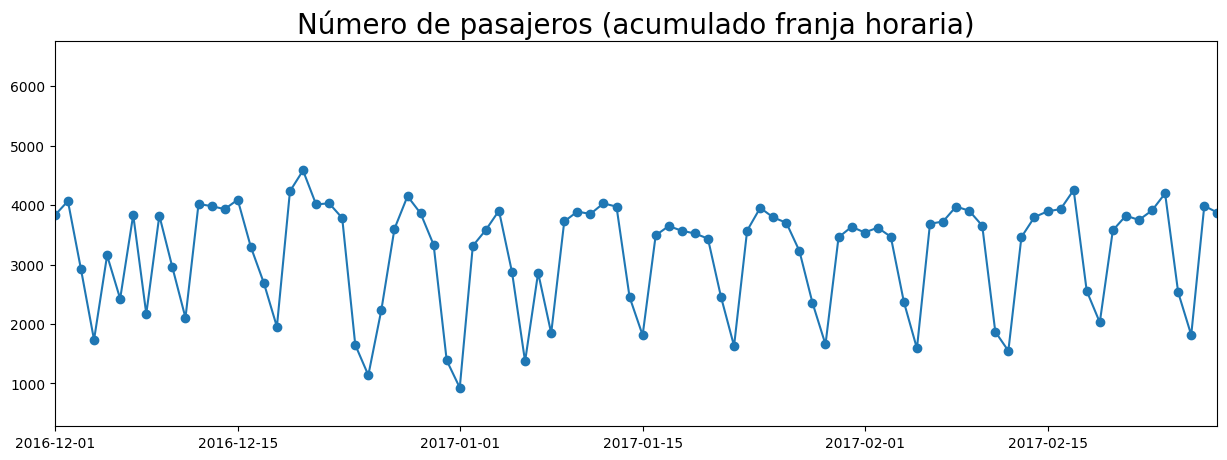

In [15]:
plt.figure(figsize=(15,5))
plt.plot(fechas, target, 'o-')
plt.title('Número de pasajeros (acumulado franja horaria)', fontsize=20)
plt.xlim([fechas[-90],fechas[-1]]);

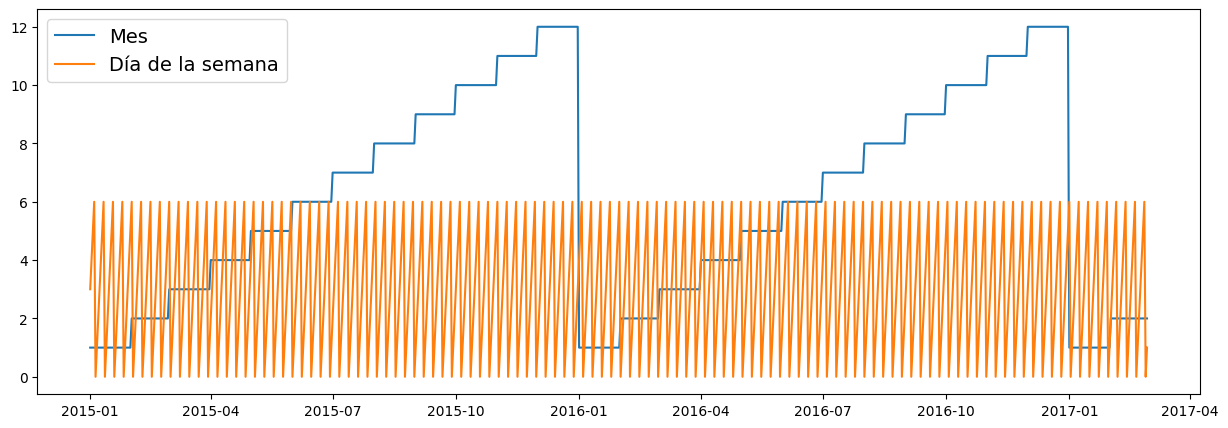

In [16]:
plt.figure(figsize=(15,5))
plt.plot(fechas, mes, label='Mes')
#plt.plot(fechas, semana, label='Semana')
plt.plot(fechas, day_of_week, label='Día de la semana')
plt.legend(fontsize=14);

Media número de viajeros    : 3065.5784810126584


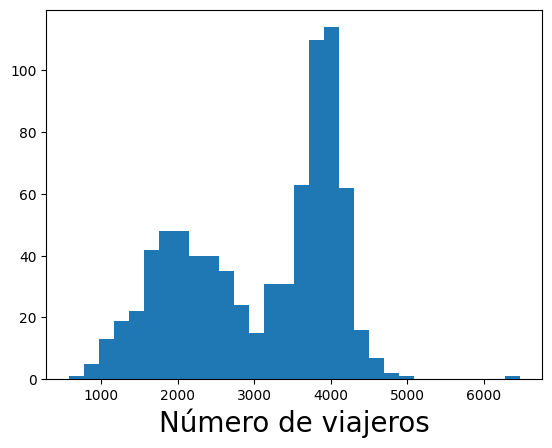

In [17]:
plt.hist(target, bins=30)
plt.xlabel('Número de viajeros', fontsize=20)
print("Media número de viajeros    :", target.mean())

## <font color="#CA3532"> **4. Transformación de la variable a predecir**

In [18]:
# Transformación de escala (ajustar el factor en función del problema)
def transform(x):
    return x/5000
def inverse_transform(x_escalado):
    return x_escalado*5000

In [19]:
transform(np.array([1,2,3]))

array([0.0002, 0.0004, 0.0006])

## <font color="#CA3532"> **5. Enventanado de datos**

In [20]:
if COLAB:
    download_file_from_google_drive(file_id='1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g',
                                    dest_file='./my_utils_series_temporales.py.zip', unzip=True)

--2026-05-28 10:14:14--  https://drive.usercontent.google.com/download?id=1LYuVxpFdsoxgl89tku6BtEH3HuYcGd2g&export=download&confirm=t&uuid=9699f0e2-e760-49fc-b12e-49f140095280
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 142.250.141.132, 2607:f8b0:4023:c0b::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|142.250.141.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2010 (2.0K) [application/octet-stream]
Saving to: ‘./my_utils_series_temporales.py.zip’

./my_utils_series_t 100%[===================>]   1.96K  --.-KB/s    in 0s      

2026-05-28 10:14:15 (18.8 MB/s) - ‘./my_utils_series_temporales.py.zip’ saved [2010/2010]



In [21]:
from my_utils_series_temporales import int2dummy, enventanar, info_enventanado, NAN

In [22]:
#?int2dummy

In [23]:
# en int2dummy el máximo marcado como entrada es un valor legal
one_hot_mes = int2dummy(mes, 1, 12)
one_hot_semana = int2dummy(semana, 0, 2)
one_hot_day_of_week = int2dummy(day_of_week, 0, 6)

In [24]:
mes.shape

(790,)

In [25]:
one_hot_mes

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [26]:
one_hot_mes.shape

(790, 12)

In [27]:
print(one_hot_day_of_week.shape, one_hot_mes.shape, one_hot_semana.shape)

(790, 7) (790, 12) (790, 3)


In [28]:
target_transf = transform(target)

series = [target_transf, festivo]
se_saben_antes = [False, True]
nombres_series = ["target_transf", "festivo"]

# Variables calendario sobre las que hemos hecho one-hot encoding
for i in range(one_hot_mes.shape[1]):
    series.append(one_hot_mes[:,i])
    nombres_series.append("mes"+str(i+1))
    se_saben_antes.append(True)

for i in range(one_hot_semana.shape[1]):
    series.append(one_hot_semana[:,i])
    nombres_series.append("semana"+str(i+1))
    se_saben_antes.append(True)

for i in range(one_hot_day_of_week.shape[1]):
    series.append(one_hot_day_of_week[:,i])
    nombres_series.append("day"+str(i+1))
    se_saben_antes.append(True)

In [29]:
print(np.shape(series))
print(np.shape(se_saben_antes))

(24, 790)
(24,)


In [30]:
lookback = 5 # lookback es otro sinónimo de W_in

# target=0 en siguiente línea quiere decir cuál es el índice del target en objeto "series":
X, y = enventanar(series, target=0, se_saben_antes=se_saben_antes,
                  W_in=lookback)

print(X.shape, np.shape(y))

(790, 5, 24) (790,)


In [31]:
info_enventanado(X[:10],y[:10],
                 nombres_series=nombres_series,
                 nombre_target="target",
                 tiempos=fechas)

10 ventanas creadas

X.shape=(10, 5, 24)  Y.shape=(10,) 

 Ventana 0: 


,?0,?1,?2,?3,?4
target_transf,nan,nan,nan,nan,nan
festivo,nan,nan,nan,nan,1.000000
mes1,nan,nan,nan,nan,1.000000
mes2,nan,nan,nan,nan,0.000000
mes3,nan,nan,nan,nan,0.000000
mes4,nan,nan,nan,nan,0.000000
mes5,nan,nan,nan,nan,0.000000
mes6,nan,nan,nan,nan,0.000000
mes7,nan,nan,nan,nan,0.000000
mes8,nan,nan,nan,nan,0.000000


 Ventana 1: 


,?0,?1,?2,?3,2015-01-01T00:00:00.000000000
target_transf,nan,nan,nan,nan,0.225000
festivo,nan,nan,nan,1.000000,0.000000
mes1,nan,nan,nan,1.000000,1.000000
mes2,nan,nan,nan,0.000000,0.000000
mes3,nan,nan,nan,0.000000,0.000000
mes4,nan,nan,nan,0.000000,0.000000
mes5,nan,nan,nan,0.000000,0.000000
mes6,nan,nan,nan,0.000000,0.000000
mes7,nan,nan,nan,0.000000,0.000000
mes8,nan,nan,nan,0.000000,0.000000


 Ventana 2: 


...

,2015-01-03 00:00:00,2015-01-04 00:00:00,2015-01-05 00:00:00,2015-01-06 00:00:00,2015-01-07 00:00:00
target_transf,0.600200,0.452000,0.553400,0.268400,0.773400
festivo,0.000000,0.000000,1.000000,0.000000,0.000000
mes1,1.000000,1.000000,1.000000,1.000000,1.000000
mes2,0.000000,0.000000,0.000000,0.000000,0.000000
mes3,0.000000,0.000000,0.000000,0.000000,0.000000
mes4,0.000000,0.000000,0.000000,0.000000,0.000000
mes5,0.000000,0.000000,0.000000,0.000000,0.000000
mes6,0.000000,0.000000,0.000000,0.000000,0.000000
mes7,0.000000,0.000000,0.000000,0.000000,0.000000
mes8,0.000000,0.000000,0.000000,0.000000,0.000000


 Ventana 8: 


,2015-01-04 00:00:00,2015-01-05 00:00:00,2015-01-06 00:00:00,2015-01-07 00:00:00,2015-01-08 00:00:00
target_transf,0.452000,0.553400,0.268400,0.773400,0.780800
festivo,0.000000,1.000000,0.000000,0.000000,0.000000
mes1,1.000000,1.000000,1.000000,1.000000,1.000000
mes2,0.000000,0.000000,0.000000,0.000000,0.000000
mes3,0.000000,0.000000,0.000000,0.000000,0.000000
mes4,0.000000,0.000000,0.000000,0.000000,0.000000
mes5,0.000000,0.000000,0.000000,0.000000,0.000000
mes6,0.000000,0.000000,0.000000,0.000000,0.000000
mes7,0.000000,0.000000,0.000000,0.000000,0.000000
mes8,0.000000,0.000000,0.000000,0.000000,0.000000


 Ventana 9: 


,2015-01-05 00:00:00,2015-01-06 00:00:00,2015-01-07 00:00:00,2015-01-08 00:00:00,2015-01-09 00:00:00
target_transf,0.553400,0.268400,0.773400,0.780800,0.735600
festivo,1.000000,0.000000,0.000000,0.000000,0.000000
mes1,1.000000,1.000000,1.000000,1.000000,1.000000
mes2,0.000000,0.000000,0.000000,0.000000,0.000000
mes3,0.000000,0.000000,0.000000,0.000000,0.000000
mes4,0.000000,0.000000,0.000000,0.000000,0.000000
mes5,0.000000,0.000000,0.000000,0.000000,0.000000
mes6,0.000000,0.000000,0.000000,0.000000,0.000000
mes7,0.000000,0.000000,0.000000,0.000000,0.000000
mes8,0.000000,0.000000,0.000000,0.000000,0.000000


In [32]:
print(X.shape)
print(np.shape(target))

(790, 5, 24)
(790,)


## <font color="#CA3532"> **6. Separación training-test**

In [33]:
train_perc  = .8
punto_corte = int(len(X)*train_perc)

In [34]:
X_train      = X[lookback:punto_corte]      # elimino los lookback primeros al tener NANs
y_train      = y[lookback:punto_corte]      # elimino los lookback primeros al tener NANs
target_train = target[lookback:punto_corte] # elimino los lookback primeros al tener NANs
fechas_train = fechas[lookback:punto_corte] # elimino los lookback primeros al tener NANs

X_test       = X[punto_corte:]
y_test       = y[punto_corte:]
target_test  = target[punto_corte:]
fechas_test  = fechas[punto_corte:]

print(np.shape(target_train))
print(np.shape(target_test))

(627,)
(158,)


In [35]:
print(X_train.shape, y_train.shape)

(627, 5, 24) (627,)


## <font color="#CA3532"> **7. Construcción del modelo con Keras**

In [36]:
#from keras.optimizers import Adam

In [37]:
model = Sequential()
model.add(LSTM(5, input_shape=(lookback, X_train.shape[2]), # kernel_regularizer='l1'
              )
         )
model.add(Dense(1, # kernel_regularizer='l1'
               )
         )
model.compile(
              loss='mean_squared_error',
              #loss="mean_absolute_error",
              optimizer='adam',
              #optimizer='rmsprop',
              #optimizer=Adam(learning_rate=0.01), # más rápido
              metrics=['mse']) # 'RMSprop'
# mean_absolute_error

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
model.optimizer.learning_rate

<Variable path=adam/learning_rate, shape=(), dtype=float32, value=0.0010000000474974513>

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5)              │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 606 (2.37 KB)

 Trainable params: 606 (2.37 KB)

 Non-trainable params: 0 (0.00 B)

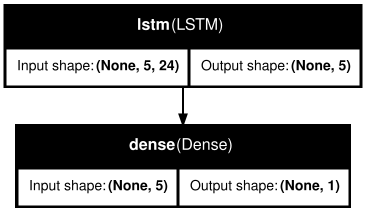

In [40]:
from IPython.display import SVG
from keras.utils import model_to_dot

if COLAB:
  display(SVG(model_to_dot(model, show_shapes=True, dpi=72).create(prog="dot",
                                                                   format="svg")))
else:
  display(SVG(model_to_dot(model, show_shapes=True).create(prog="dot",
                                                           format="svg")))

In [41]:
def grafica_entrenamiento(tr_mse, val_mse):
    ax=plt.figure(figsize=(10,4)).gca()
    plt.plot(1+np.arange(len(tr_mse)), tr_mse)
    plt.plot(1+np.arange(len(val_mse)), val_mse)
    plt.title('mse del modelo', fontsize=18)
    plt.xlabel('epoca', fontsize=18)
    plt.ylabel('mse', fontsize=18)
    plt.legend(['entrenamiento', 'validación'], loc='upper left')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


Epoch 1: val_mse improved from None to 0.51453, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.51453 to 0.45298, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.45298 to 0.39869, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.39869 to 0.35072, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.35072 to 0.30741, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.01123 to 0.01091, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.01091 to 0.01069, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.01069 to 0.01046, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.01046 to 0.01031, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


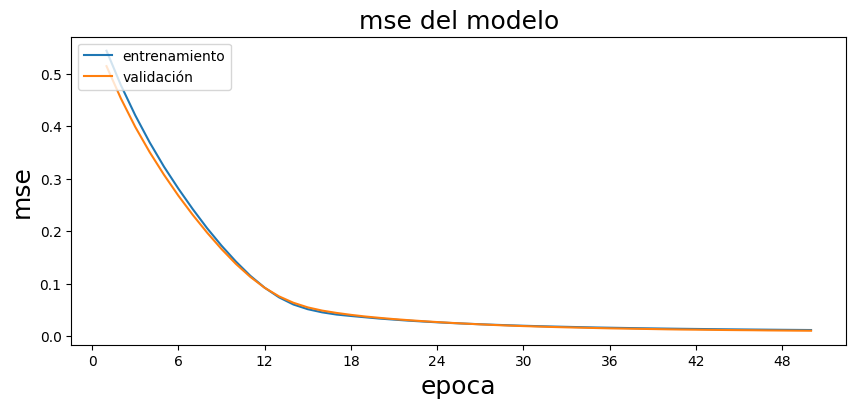


Epoch 1: val_mse improved from 0.01031 to 0.01013, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.01013 to 0.00999, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00999 to 0.00982, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00982 to 0.00961, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00961 to 0.00947, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00632 to 0.00621, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00621

Epoch 1: val_mse did not improve from 0.00621

Epoch 1: val_mse improved from 0.00621 to 0.00616, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00616 to 0.00611, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00611 to 0.00606, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


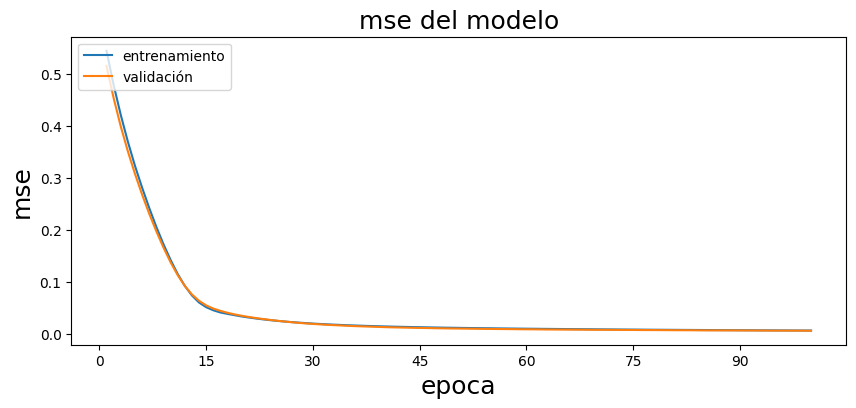


Epoch 1: val_mse improved from 0.00606 to 0.00602, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00602 to 0.00599, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00599

Epoch 1: val_mse improved from 0.00599 to 0.00593, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00593 to 0.00582, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00582 to 0.00582, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00491 to 0.00489, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00489

Epoch 1: val_mse did not improve from 0.00489

Epoch 1: val_mse did not improve from 0.00489

Epoch 1: val_mse did not improve from 0.00489

Epoch 1: val_mse improved from 0.00489 to 0.00482, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00482

Epoch 1: val_mse improved from 0.00482 to 0.00477, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00477 to 0.00475, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00475

Epoch 1: val_mse did not improve from 0.00475


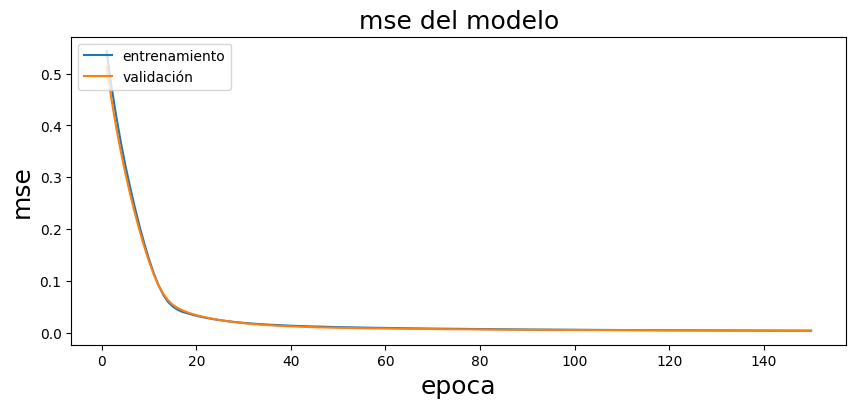


Epoch 1: val_mse did not improve from 0.00475

Epoch 1: val_mse improved from 0.00475 to 0.00472, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00472 to 0.00471, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00471 to 0.00468, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00468 to 0.00465, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00465 to 0.00464, saving model to model_current_best.h5


...


Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00424

Epoch 1: val_mse did not improve from 0.00424

Epoch 1: val_mse did not improve from 0.00424

Epoch 1: val_mse improved from 0.00424 to 0.00421, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00421

Epoch 1: val_mse improved from 0.00421 to 0.00420, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse did not improve from 0.00420

Epoch 1: val_mse did not improve from 0.00420

Epoch 1: val_mse did not improve from 0.00420

Epoch 1: val_mse did not improve from 0.00420

Epoch 1: val_mse did not improve from 0.00420

Epoch 1: val_mse improved from 0.00420 to 0.00415, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5

Epoch 1: val_mse improved from 0.00415 to 0.00415, saving model to model_current_best.h5



Epoch 1: finished saving model to model_current_best.h5


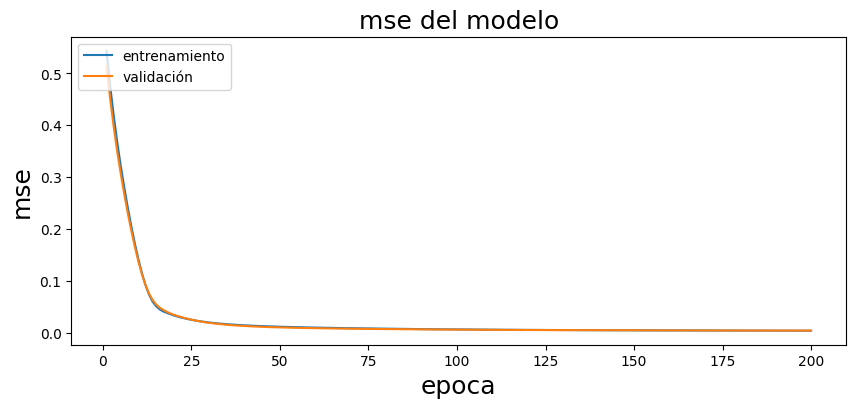

In [42]:
epochs = 200
batch_size = 64
Nval = 200
control_sobreajuste_val = True

if not control_sobreajuste_val:
    history = model.fit(X_train, y_train, epochs=epochs,
                        batch_size=batch_size, verbose=2)
else:
    acum_tr_mse = []
    acum_val_mse = []
    modelpath="model_current_best.h5"
    checkpoint = ModelCheckpoint(modelpath, monitor='val_mse', verbose=2, # val_mean_squared_error
                                 save_best_only=True,
                                 mode='min') # graba sólo los que mejoran en validación

    callbacks_list = [checkpoint]

    for e in range(epochs):
        aux = X_train[:-Nval]
        history = model.fit(aux, y_train[:-Nval],
                            batch_size=batch_size,
                            epochs=1,
                            callbacks=callbacks_list,
                            verbose=0,
                            validation_data=(X_train[-Nval:], y_train[-Nval:]))

        acum_tr_mse  += history.history['mse'] # mean_squared_error
        acum_val_mse += history.history['val_mse'] # val_mean_squared_error

        if (e+1)%50 == 0:
            grafica_entrenamiento(acum_tr_mse, acum_val_mse)

In [43]:
model = load_model(modelpath) # recupero el mejor modelo en validación

## <font color="#CA3532"> **8. Chequeo del modelo (predicción a un día)**

In [44]:
y_train_prediction = model.predict(X_train).flatten()
y_test_prediction = model.predict(X_test).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [45]:
target_train_pred = inverse_transform(y_train_prediction)
target_test_pred  = inverse_transform(y_test_prediction)

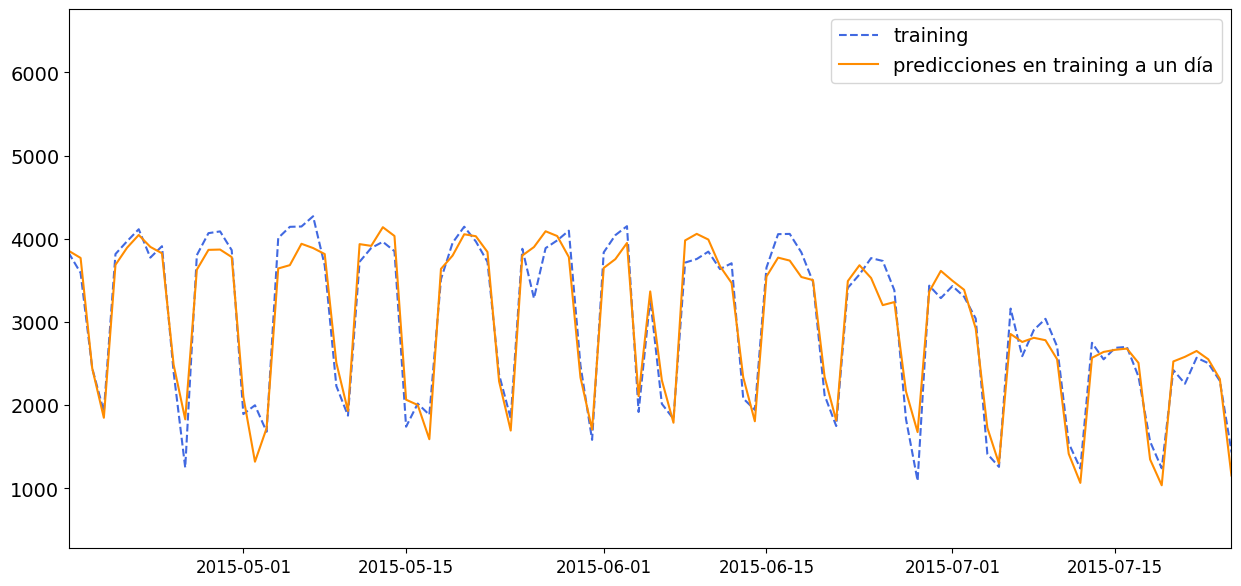

In [46]:
plt.figure(figsize=(15,7))
plt.plot(fechas_train, target_train, '--', c='royalblue',
         label="training")
plt.plot(fechas_train, target_train_pred,  c='darkorange',
         label="predicciones en training a un día")

plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlim([fechas_train[100],fechas_train[200]])
plt.legend(fontsize=14);

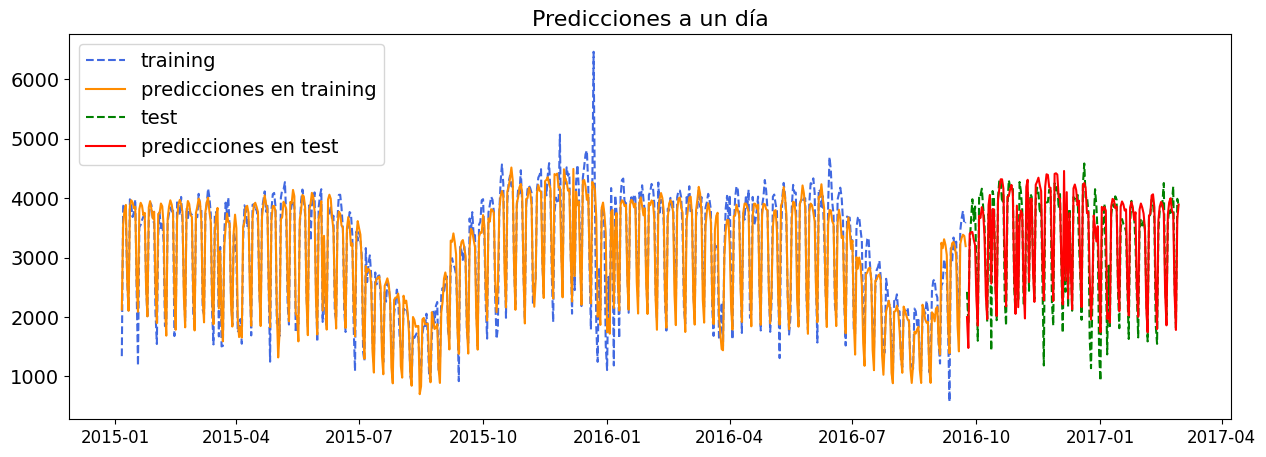

In [47]:
plt.figure(figsize=(15,5))
plt.plot(fechas_train, target_train, '--', c='royalblue',
         label='training')
plt.plot(fechas_train, target_train_pred,  c='darkorange',
         label='predicciones en training')
plt.plot(fechas_test, target_test, '--',   c='green',
         label='test')
plt.plot(fechas_test, target_test_pred,    c='red',
         label='predicciones en test')
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.title('Predicciones a un día', fontsize=16)
plt.legend(fontsize=14);

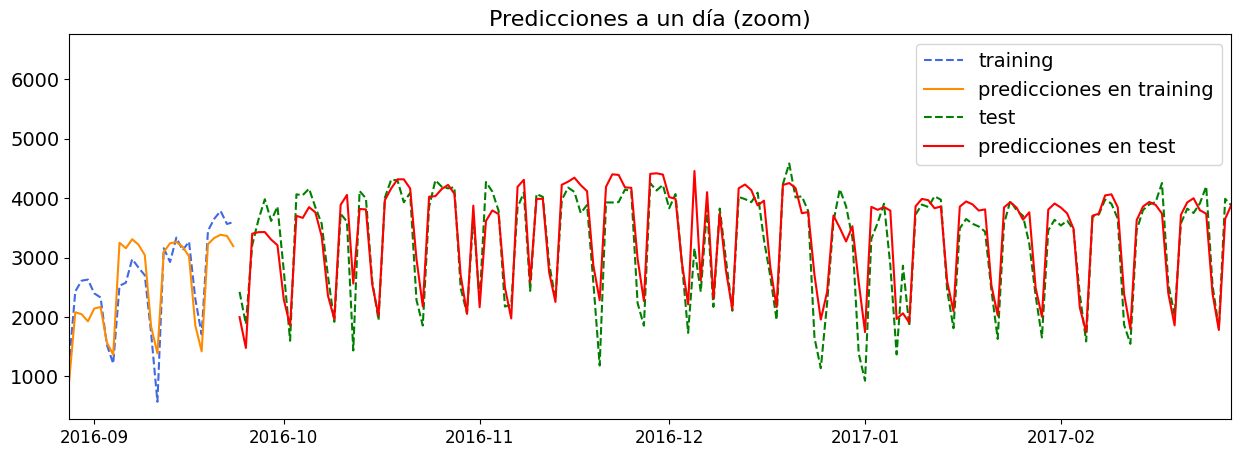

In [48]:
plt.figure(figsize=(15,5))
plt.plot(fechas_train, target_train, '--', c='royalblue',
         label='training')
plt.plot(fechas_train, target_train_pred,  c='darkorange',
         label='predicciones en training')
plt.plot(fechas_test, target_test, '--',   c='green',
         label='test')
plt.plot(fechas_test, target_test_pred,    c='red',
         label='predicciones en test')
plt.title('Predicciones a un día (zoom)', fontsize=16)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlim([fechas_train[600],fechas_test[-1]]);

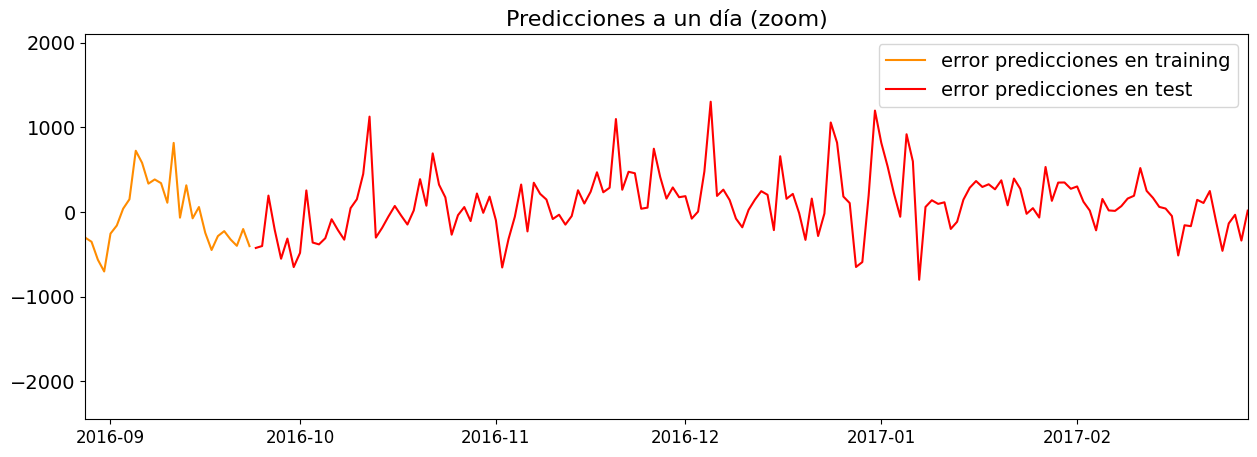

In [49]:
plt.figure(figsize=(15,5))
plt.plot(fechas_train, target_train_pred - target_train,  c='darkorange',
         label='error predicciones en training')
plt.plot(fechas_test, target_test_pred - target_test,    c='red',
         label='error predicciones en test')
plt.title('Predicciones a un día (zoom)', fontsize=16)
plt.legend(fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=14)
plt.xlim([fechas_train[600],fechas_test[-1]]);

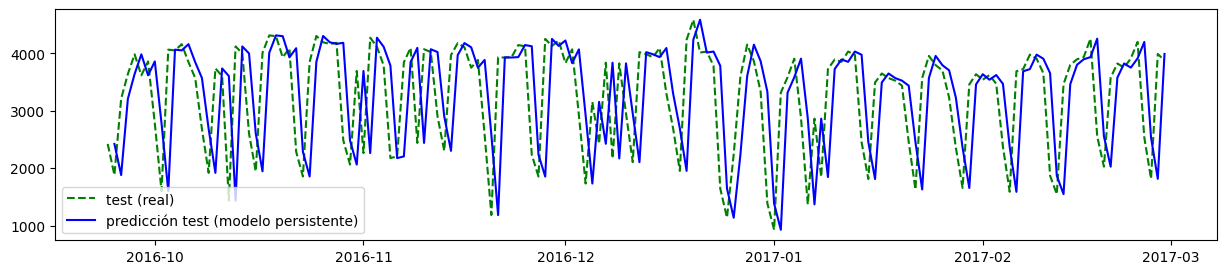

In [50]:
plt.figure(figsize=(15,3))
plt.plot(fechas_test, target_test, '--',   c='green',
         label='test (real)')
plt.plot(fechas_test[1:], target_test[:-1], '-',   c='blue',
         label='predicción test (modelo persistente)')
plt.legend();

In [51]:
# Modelos de referencia: modelo persistente (a 1 día, 7 días etc.)

# R2 scores
print("R2 del modelo en training      : ",
      R2_score(target_train[1:], target_train_pred[1:]))
print("R2 del modelo en test          : ",
      R2_score(target_test, target_test_pred))
print("R2 modelo persistente 1 día    : ",
      R2_score(target_test[1:], target_test[:-1]))
print("R2 modelo persistente 1 semana : ",
      R2_score(target_test[7:], target_test[:-7]))
print("R2 modelo persistente 4 semanas: ",
      R2_score(target_test[28:], target_test[:-28]))
print("R2 modelo persistente 1 año: ",
      R2_score(target_train[7*52:], target_train[:-7*52]))

R2 del modelo en training      :  0.9026553630828857
R2 del modelo en test          :  0.834475040435791
R2 modelo persistente 1 día    :  -0.44768351889101354
R2 modelo persistente 1 semana :  0.3743300534633949
R2 modelo persistente 4 semanas:  0.48525679455105053
R2 modelo persistente 1 año:  0.6779203301147232


In [52]:
# R2(y_real, y_predicho) = 1 - MSE/VAR(y real)
# r2(v1, v2) # correlación lineal

# r2(precio en euros, precio en céntimos de euros) = 1.
# ** R2(precio en euros, precio en céntimos de euros) = 1 - promedio((precio1-precio2)^2)/VAR(precio1) << -1

In [53]:
# RMSEs
sqrt = np.sqrt
print("RMSE del modelo en training      : ",
      sqrt(mean_squared_error(target_train[1:],
                              target_train_pred[1:])))
print("RMSE del modelo en test          : ",
      sqrt(mean_squared_error(target_test,
                              target_test_pred)))
print("RMSE modelo persistente 1 día    : ",
      sqrt(mean_squared_error(target_test[1:],
                              target_test[:-1])))
print("RMSE modelo persistente 1 semana : ",
      sqrt(mean_squared_error(target_test[7:],
                              target_test[:-7])))
print("RMSE modelo persistente 4 semanas: ",
      sqrt(mean_squared_error(target_test[28:],
                              target_test[:-28])))

RMSE del modelo en training      :  315.024131020149
RMSE del modelo en test          :  369.70275222129465
RMSE modelo persistente 1 día    :  1093.8023843688381
RMSE modelo persistente 1 semana :  724.5713553588926
RMSE modelo persistente 4 semanas:  654.1568971996292


## <font color="#CA3532"> **9. Predicciones a varios días en test mediante un modelo auto-regresivo**

In [59]:
def step_autoregresivo(model, ventana, X, i):
    # ventana: va a tener dimensiones (1, lookback, n_variables)
    # El target está en (0,:,0)
    # La posición (0,0,0) es el target en el día más antiguo de la ventana
    # La posición (0,0,-1) es el target en el día más reciente de la ventana
    # Las variables calendario están en (0,:,1:)
    # Las variables calendario para el último día de la ventana están en (0,-1,1:)

    z = model.predict(ventana, verbose=0)[0,0] # predicción nueva
    target_pred = inverse_transform(z)
    ventana_nueva = None
    if i < (len(X)-1):
        ventana_nueva = np.zeros(ventana.shape)
        # muevo un día hacia atrás todas las variables de la ventana:
        ventana_nueva[0,:-1,:] = ventana[0,1:,:].copy()

        # introduzco las variables calendario para el último día de la ventana:
        ventana_nueva[0,-1,1:] = X[i+1,-1,1:]

        # meto la predicción como última obervación del target:
        ventana_nueva[0,-1,0] = z


    return target_pred, ventana_nueva

In [60]:
def autoregresivo(model, X):
    ventana = np.array([X[0]]).copy()
    salidas = []
    for i in range(len(X)):
        target_pred, ventana_nueva = step_autoregresivo(model, ventana, X, i)
        salidas.append(target_pred)
        ventana = ventana_nueva

    return salidas

In [61]:
sal = autoregresivo(model, X_test)

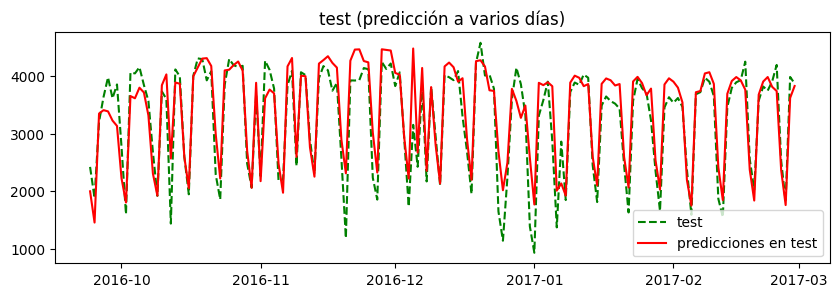

In [62]:
fig = plt.figure(figsize=(10,3))
ax = fig.add_subplot(1,1,1)
ax.plot(fechas_test, target_test, '--g', label='test')
plt.plot(fechas_test, sal, 'r', label='predicciones en test')
plt.title('test (predicción a varios días)')
plt.legend();

In [63]:
preds = pd.DataFrame({"fecha": fechas_test,
                      "n_pasajeros_estimados":sal})
preds.to_csv("predicciones.csv")
preds

,fecha,n_pasajeros_estimados
0,2016-09-24,1999.073608
1,2016-09-25,1455.069946
2,2016-09-26,3352.652588
3,2016-09-27,3412.137939
4,2016-09-28,3390.698730
...,...,...
153,2017-02-24,3744.429932
154,2017-02-25,2368.663818
155,2017-02-26,1759.790894
156,2017-02-27,3624.680908
